In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
A=pd.read_excel("/content/A.xlsx")
B=pd.read_excel("/content/B.xlsx")
C=pd.read_excel("/content/C.xlsx")
D=pd.read_excel("/content/D.xlsx")

# 찐 최종

[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
 Participating: ['A', 'B', 'C', 'D']
  [Client A] Local Accuracy: 0.6840
  [Client B] Local Accuracy: 0.7421
  [Client C] Local Accuracy: 0.7136
  [Client D] Local Accuracy: 0.8037
[Round 1] Global Accuracy: 0.4962 → 0.6859

=== Round 2 ===
 Participating: ['A', 'D']
  [Client A] Local Accuracy: 0.7087
  [Client D] Local Accuracy: 0.7914
[Round 2] Global Accuracy: 0.6859 → 0.7066

=== Round 3 ===
 Participating: ['A', 'B', 'C']
  [Client A] Local Accuracy: 0.7211
  [Client B] Local Accuracy: 0.8000
  [Client C] Local Accuracy: 0.7453
[Round 3] Global Accuracy: 0.7066 → 0.7123

=== Round 4 ===
 Participating: ['A', 'B', 'C']
  [Client A] Local Accuracy: 0.7343
  [Client

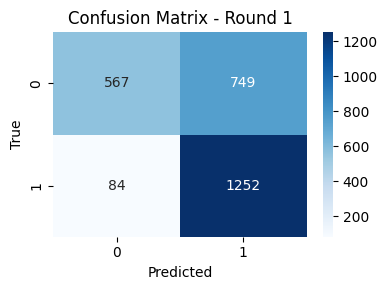

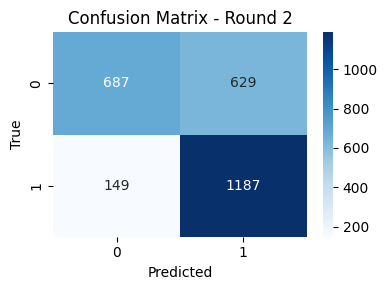

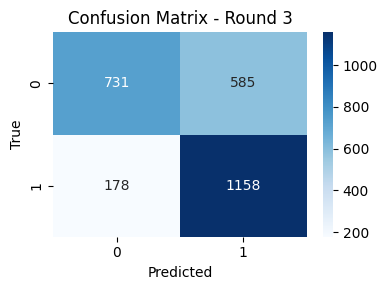

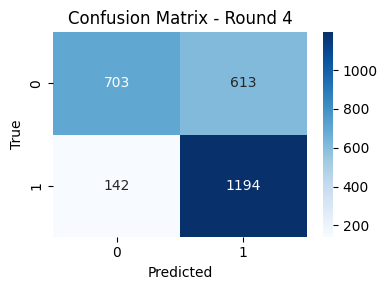

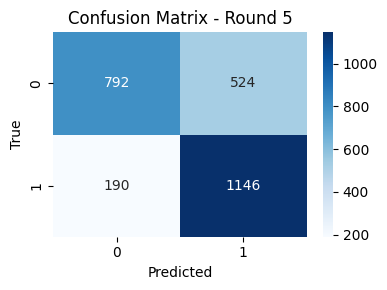

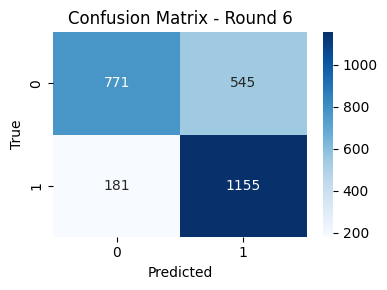

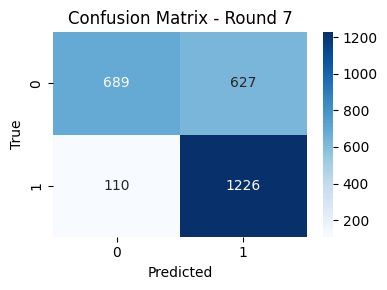

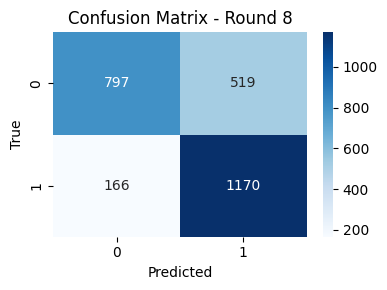

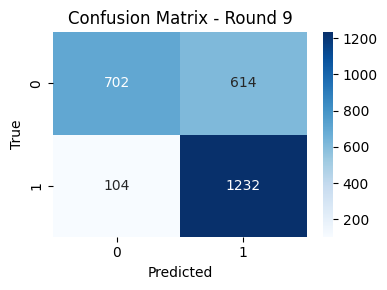

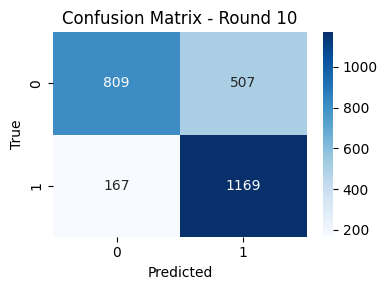

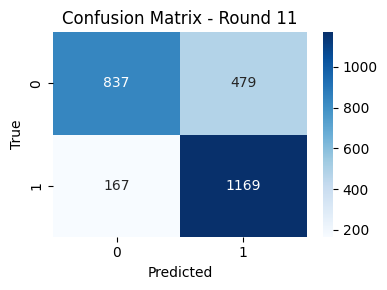

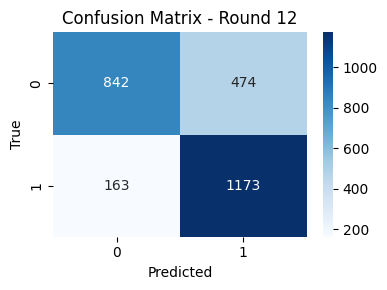

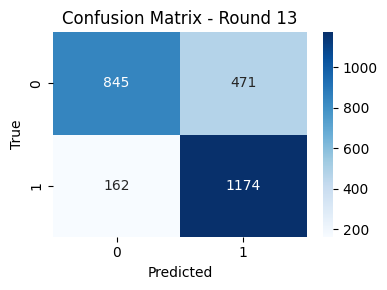

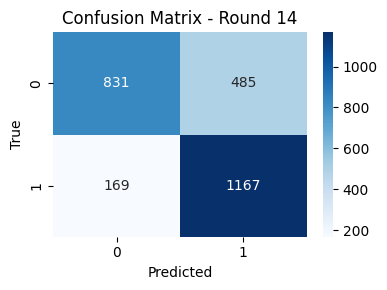

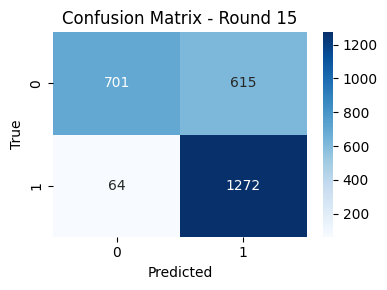

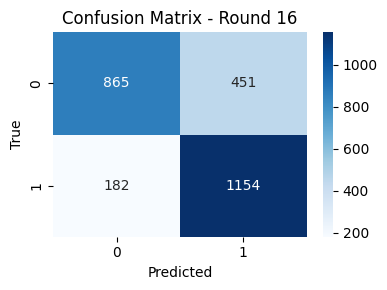

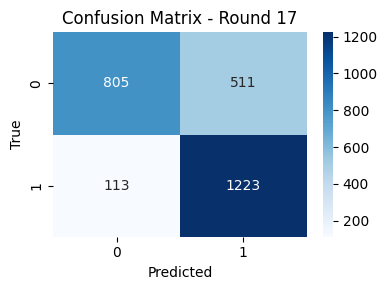

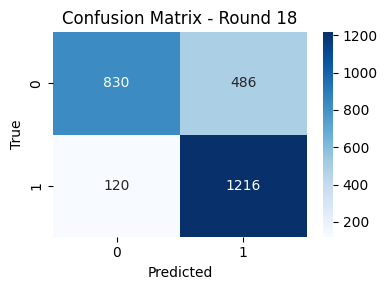

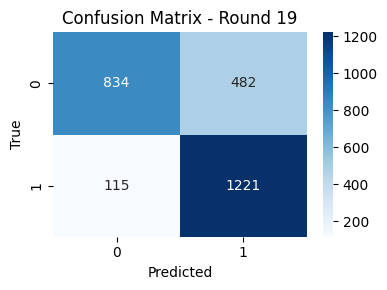

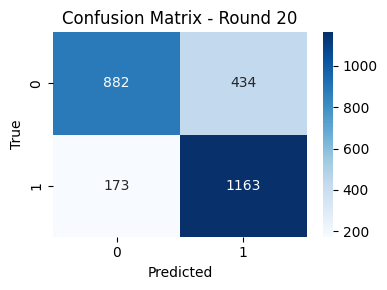

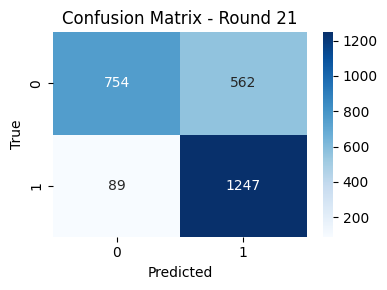

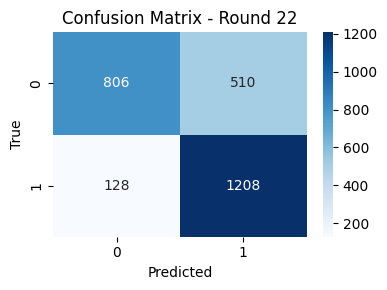

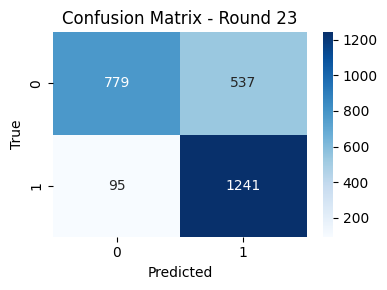

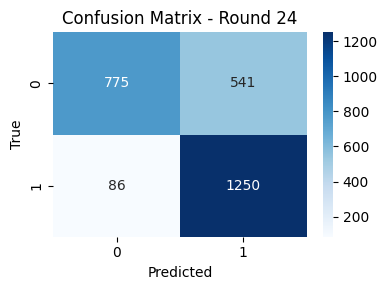

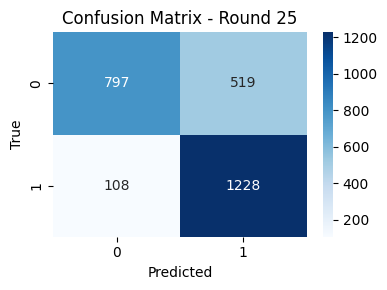

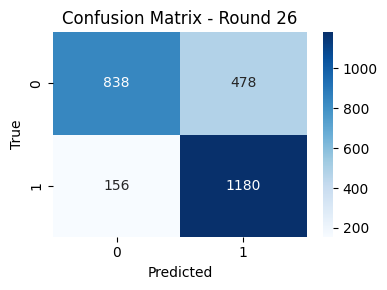

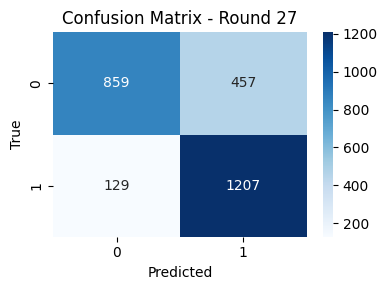

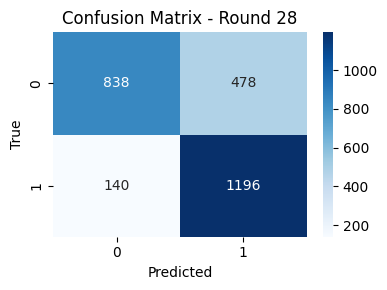

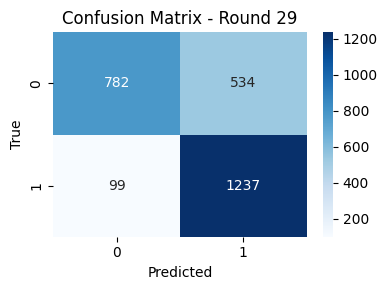

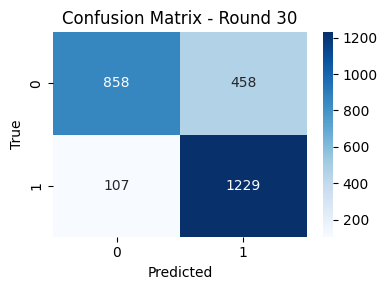

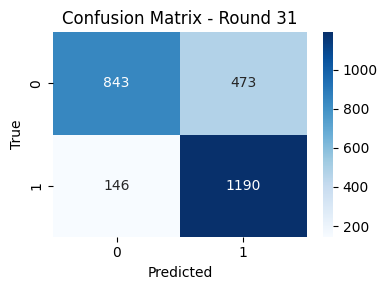

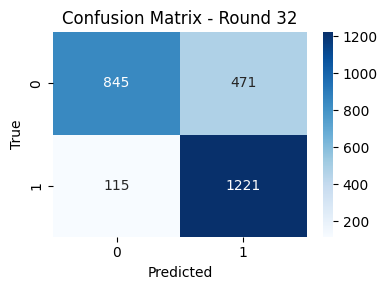

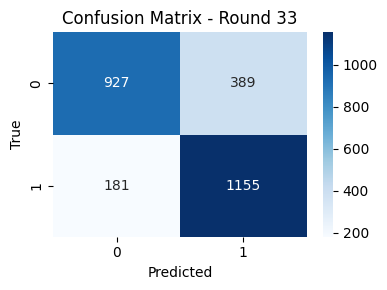

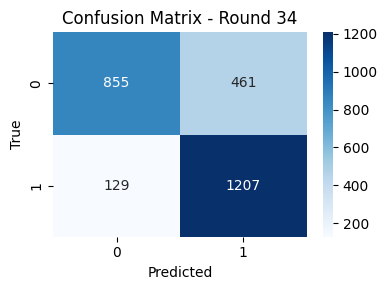

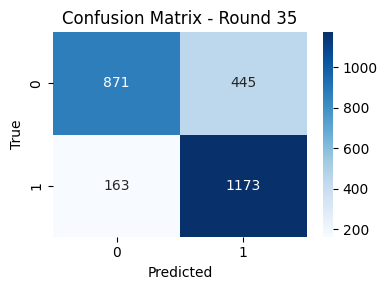

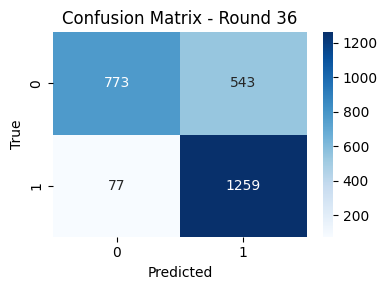

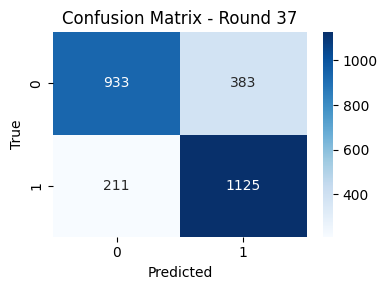

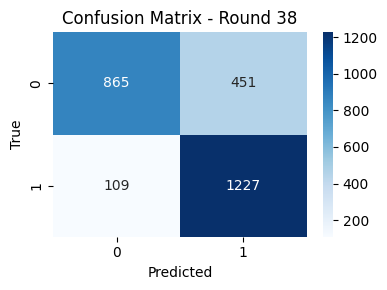

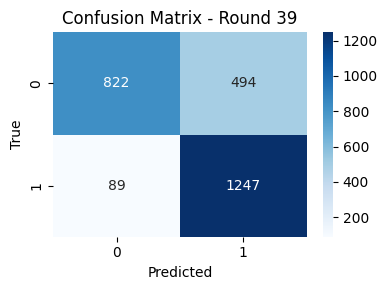

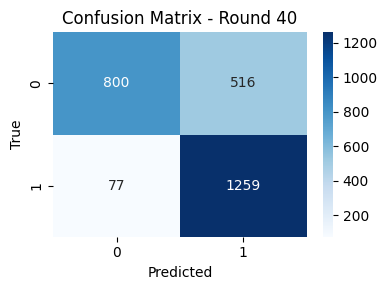

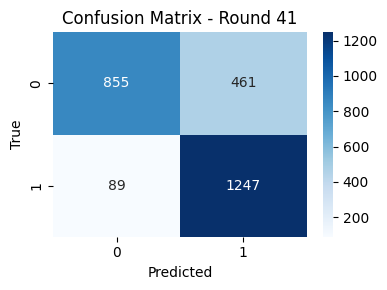

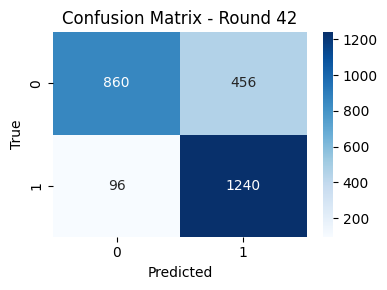

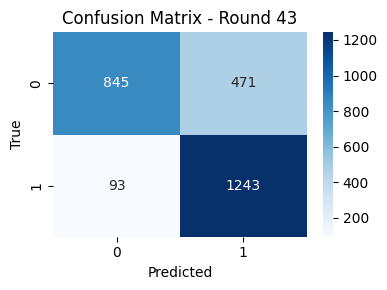

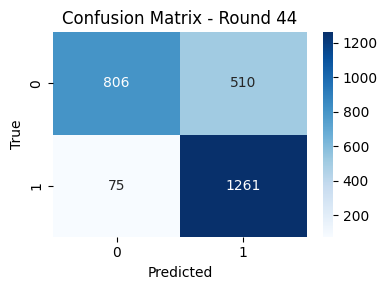

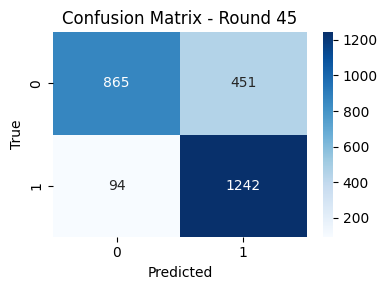

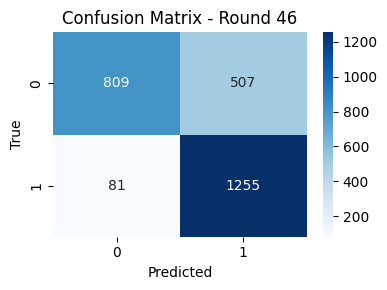

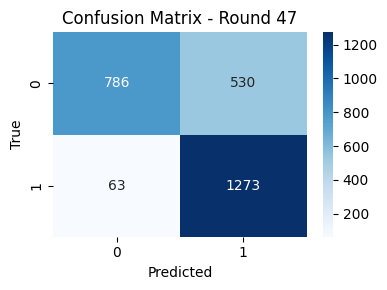

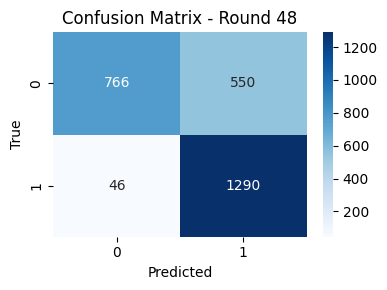

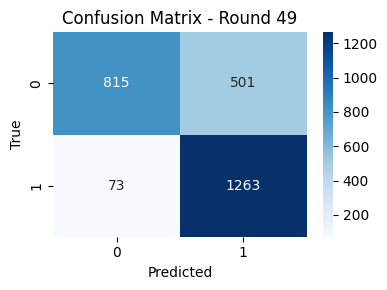

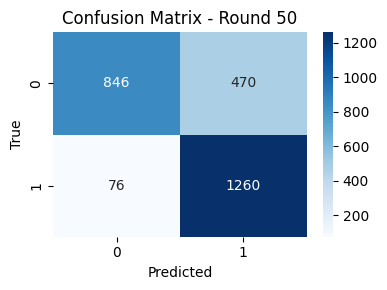

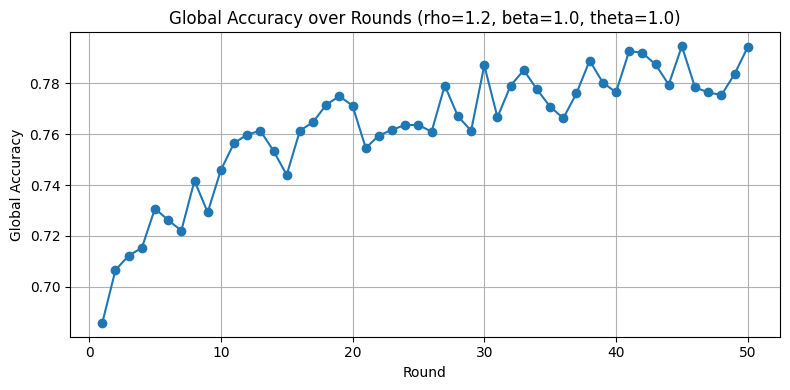

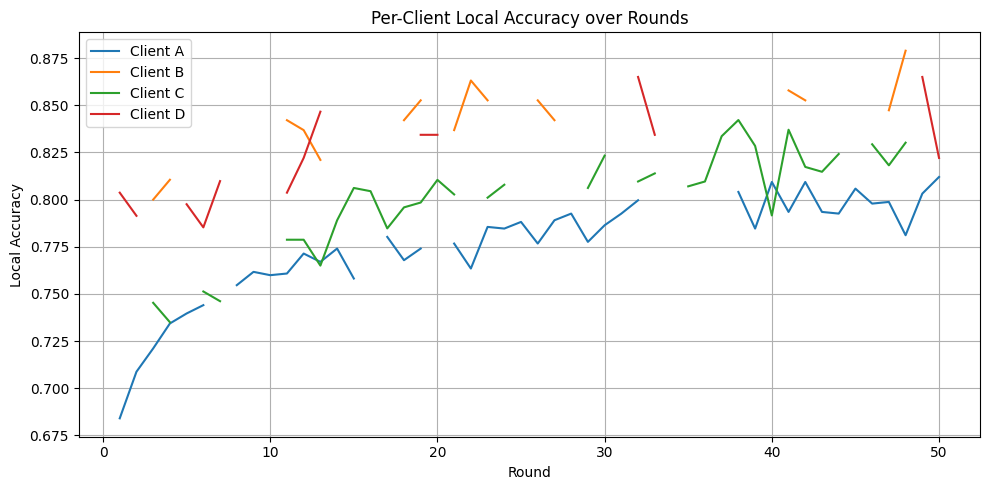

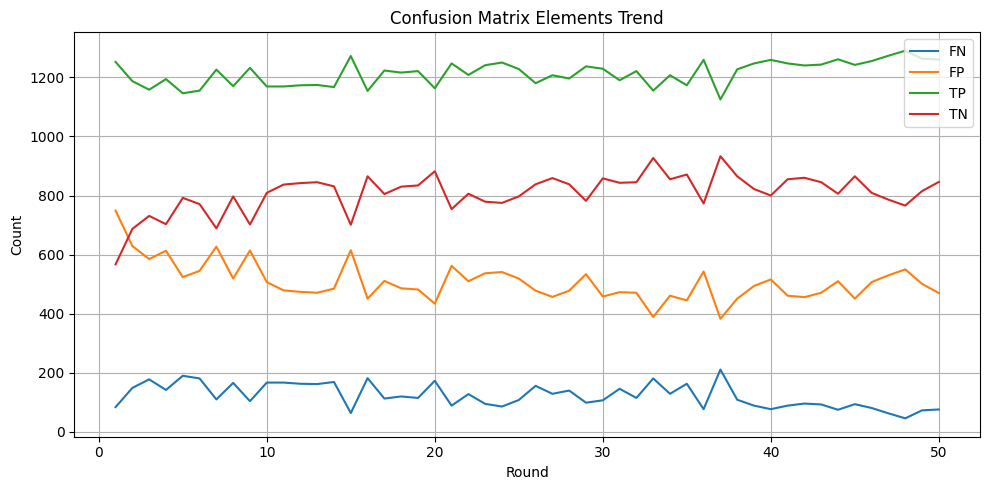

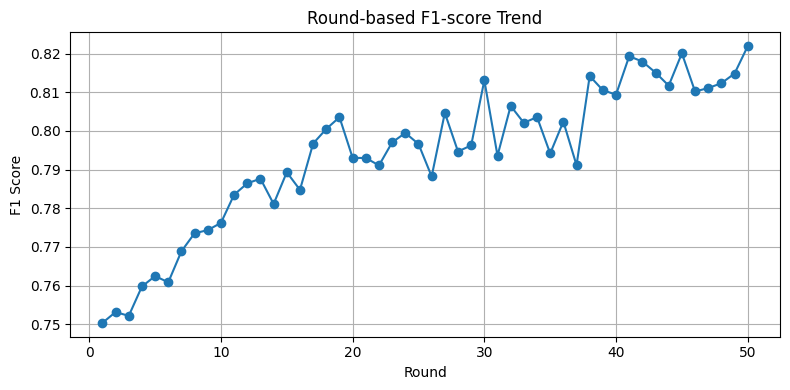

In [3]:
import os, math, copy, random, argparse
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 0) 재현성
# =========================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = [
    'Short_Shot_1','Bubble_1','Exfoliation_1','Blow_Hole_1','Deformation_1'
]

RHO   = 1.2
BETA  = 1.0
THETA = 1.0


# =========================================================
# 1) 데이터 로드 + SMOTE
# =========================================================
def oversample_dataset(X, y):
    sm = SMOTE(random_state=SEED, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path):
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]

    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()

        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)

        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test  = n - n_train

        tr, te = random_split(allset, [n_train, n_test], generator=torch.Generator().manual_seed(SEED))

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid]   = {"n_samples": len(y), "class_counts": pd.Series(v["y"]).value_counts().to_dict()}

    return clients, metas, list(cols)


# =========================================================
# 2) Deep MLP 모델
# =========================================================
class DeepMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# =========================================================
# 3) Focal Loss
# =========================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()


# =========================================================
# 4) αᵢ 구성요소 계산
# =========================================================
def compute_ci(counts, eps_frac=0.05, min_samples=1):
    K = len(counts)
    total = sum(counts.values())
    if K == 0 or total == 0:
        return 1e-8

    H = -sum((c / total) * math.log(c / total) for c in counts.values() if c > 0)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK
    H_tilde = max(H, H_floor)

    k_i = sum(1 for c in counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))


def aggregate_with_softmax_weights(state_dicts, alpha_components,
                                   rho, beta, theta, use_fedbn=True):
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"]**rho + 1e-12) +
            math.log(comp["c_i"]**beta + 1e-12) +
            math.log(comp["t_i"]**theta + 1e-12)
        )

    max_log = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_log) for cid in logits}
    total_exp = sum(exp_logits.values())
    alphas = {cid: exp_logits[cid] / total_exp for cid in logits}

    base_sd = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items())
            global_sd[k] = agg.clone()

    return global_sd


# =========================================================
# 5) Local Train (FedProx)
# =========================================================
def local_train(base_model, dataset, lr, epochs, device, global_params, mu):
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()

            logits = model(x)
            loss = crit(logits, y)

            if mu > 0:
                prox = sum(torch.norm(p - g)**2 for p, g in zip(model.parameters(), global_params))
                loss += 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()


# =========================================================
# 6) 평가 + Confusion Matrix
# =========================================================
def evaluate(model, dataset, device, threshold=0.5, return_preds=False):
    model.eval()
    loader = DataLoader(dataset, batch_size=256)

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()

            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    if return_preds:
        return acc, y_true, y_pred
    return acc


# =========================================================
# 7) Federated Learning Main Loop
# =========================================================
parser = argparse.ArgumentParser()
parser.add_argument("--rounds", type=int, default=50)
parser.add_argument("--mu",     type=float, default=0.003)
parser.add_argument("--ft_epochs", type=int, default=5)
args,_ = parser.parse_known_args()

paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
clients, metas, cols = build_clients(paths)

device = "cuda" if torch.cuda.is_available() else "cpu"

input_dim = clients["A"]["all"].tensors[0].shape[1]
global_model = DeepMLP(input_dim).to(device)

participation_probs = {
    "A": 0.9,
    "C": 0.7,
    "B": 0.4,
    "D": 0.4
}

combined_test = torch.utils.data.ConcatDataset([v["test"] for v in clients.values()])

global_acc_history = []
local_acc_history = {cid: [] for cid in clients}
round_conf_matrices = {}
round_f1_scores = []
round_FN = []
round_TN = []
round_FP = []
round_TP = []


# =========================================================
# Training Loop
# =========================================================
for rnd in range(1, args.rounds+1):
    print(f"\n=== Round {rnd} ===")

    selected = [cid for cid in clients if random.random() < participation_probs[cid]]
    if len(selected) == 0:
        selected = [random.choice(list(clients.keys()))]

    print(" Participating:", selected)

    state_dicts = {}
    alpha_components = {}

    before_acc = evaluate(global_model, combined_test, device)

    global_params = [p.detach().clone() for p in global_model.parameters()]

    for cid in clients:
        local_acc_history[cid].append(float('nan'))

    for cid in selected:
        ds_train = clients[cid]["train"]

        labels = [int(y) for _,y in ds_train]
        class_counts = pd.Series(labels).value_counts().to_dict()

        state_dict = local_train(
            base_model=global_model,
            dataset=ds_train,
            lr=0.0008,
            epochs=5,
            device=device,
            global_params=global_params,
            mu=args.mu
        )
        state_dicts[cid] = state_dict

        n_i = math.sqrt(metas[cid]["n_samples"])
        c_i = compute_ci(class_counts)
        t_i = participation_probs[cid]

        alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

        temp_model = copy.deepcopy(global_model)
        temp_model.load_state_dict(state_dict)
        local_acc = evaluate(temp_model, clients[cid]["test"], device)
        local_acc_history[cid][-1] = local_acc
        print(f"  [Client {cid}] Local Accuracy: {local_acc:.4f}")

    new_global_sd = aggregate_with_softmax_weights(
        state_dicts, alpha_components, RHO, BETA, THETA, use_fedbn=True
    )
    global_model.load_state_dict(new_global_sd)

    acc_after, yt, yp = evaluate(
        global_model, combined_test, device, return_preds=True
    )
    global_acc_history.append(acc_after)

    print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {acc_after:.4f}")

    cm = confusion_matrix(yt, yp)
    round_conf_matrices[rnd] = cm

    TN, FP, FN, TP = cm.ravel()
    round_FN.append(FN)
    round_FP.append(FP)
    round_TP.append(TP)
    round_TN.append(TN)
    round_f1_scores.append(f1_score(yt, yp))


# =========================================================
# Final Evaluation
# =========================================================
print("\n=== Heatmap for All Rounds ===")
for rnd, cm in round_conf_matrices.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - Round {rnd}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


# =========================================================
# Global Accuracy Plot
# =========================================================
rounds_axis = list(range(1, args.rounds+1))

plt.figure(figsize=(8,4))
plt.plot(rounds_axis, global_acc_history, marker='o')
plt.xlabel("Round")
plt.ylabel("Global Accuracy")
plt.title(f"Global Accuracy over Rounds (rho={RHO}, beta={BETA}, theta={THETA})")
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# Local Accuracy per Client
# =========================================================
plt.figure(figsize=(10,5))
for cid in clients.keys():
    plt.plot(rounds_axis, local_acc_history[cid], label=f"Client {cid}")
plt.xlabel("Round")
plt.ylabel("Local Accuracy")
plt.title("Per-Client Local Accuracy over Rounds")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# FN / FP / TP / TN Trend Plot
# =========================================================
plt.figure(figsize=(10,5))
plt.plot(rounds_axis, round_FN, label='FN')
plt.plot(rounds_axis, round_FP, label='FP')
plt.plot(rounds_axis, round_TP, label='TP')
plt.plot(rounds_axis, round_TN, label='TN')
plt.legend()
plt.xlabel("Round")
plt.ylabel("Count")
plt.title("Confusion Matrix Elements Trend")
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# F1-score Trend
# =========================================================
plt.figure(figsize=(8,4))
plt.plot(rounds_axis, round_f1_scores, marker='o')
plt.xlabel("Round")
plt.ylabel("F1 Score")
plt.title("Round-based F1-score Trend")
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
print(global_model.state_dict().keys())

odict_keys(['net.0.weight', 'net.0.bias', 'net.1.weight', 'net.1.bias', 'net.1.running_mean', 'net.1.running_var', 'net.1.num_batches_tracked', 'net.4.weight', 'net.4.bias', 'net.5.weight', 'net.5.bias', 'net.5.running_mean', 'net.5.running_var', 'net.5.num_batches_tracked', 'net.8.weight', 'net.8.bias', 'net.9.weight', 'net.9.bias', 'net.9.running_mean', 'net.9.running_var', 'net.9.num_batches_tracked', 'net.12.weight', 'net.12.bias'])


[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 ===
 Participating: ['A', 'B', 'C', 'D']
  [Client A] Local Accuracy: 0.6858
  [Client B] Local Accuracy: 0.7684
  [Client C] Local Accuracy: 0.7084
  [Client D] Local Accuracy: 0.8037
[Round 1] Global Accuracy: 0.4925 → 0.6893

 Confusion Matrix (Round 1)
[[ 578  738]
 [  86 1250]]

=== Round 2 ===
 Participating: ['A', 'D']
  [Client A] Local Accuracy: 0.7034
  [Client D] Local Accuracy: 0.7914
[Round 2] Global Accuracy: 0.6893 → 0.6919

 Confusion Matrix (Round 2)
[[ 654  662]
 [ 155 1181]]

=== Round 3 ===
 Participating: ['A', 'B', 'C']
  [Client A] Local Accuracy: 0.7158
  [Client B] Local Accuracy: 0.8000
  [Client C] Local Accuracy: 0.7367
[Round 3] Global Accuracy

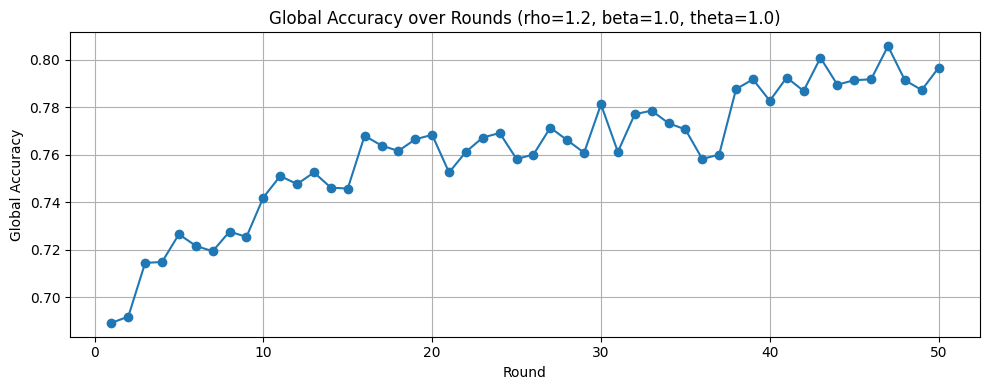

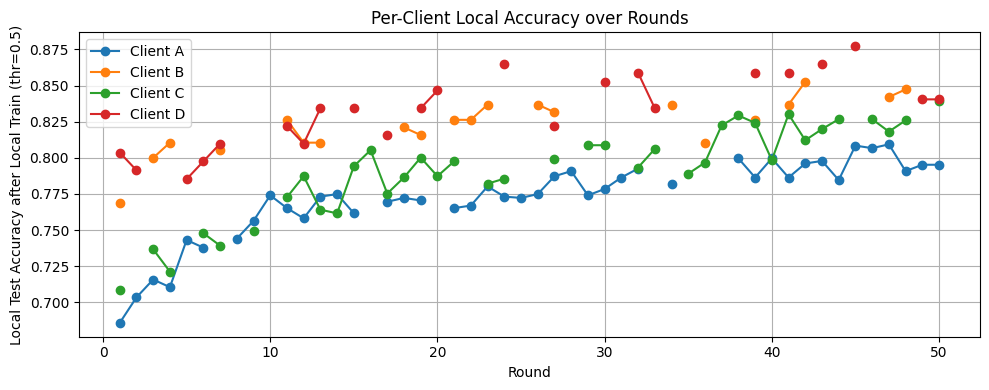

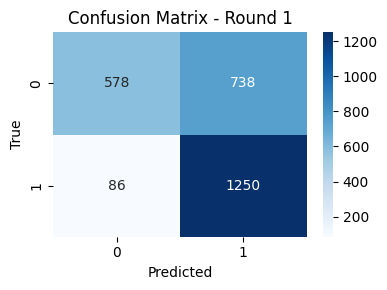

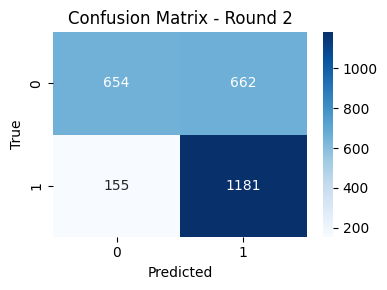

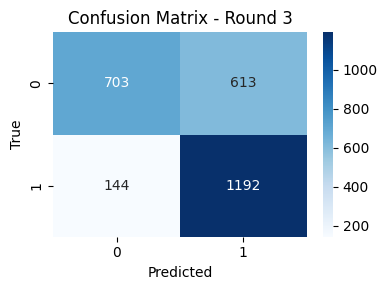

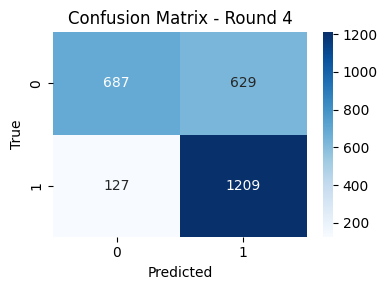

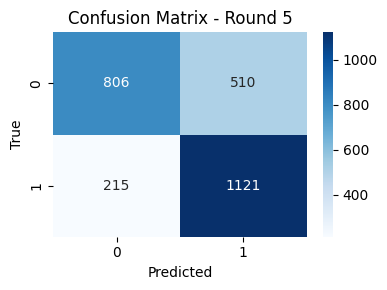

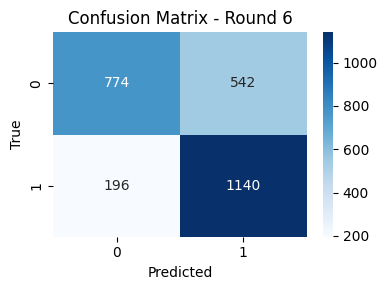

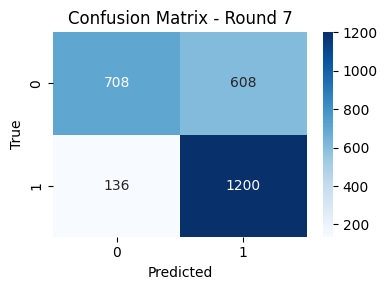

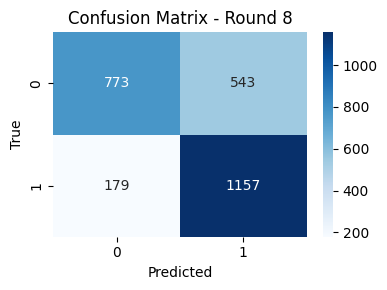

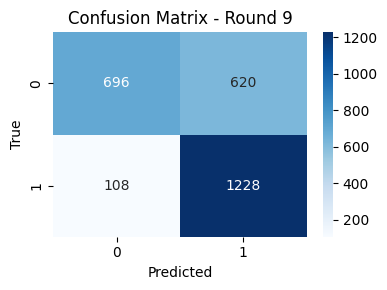

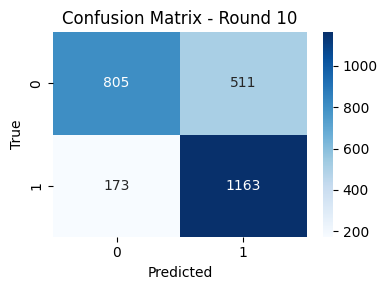

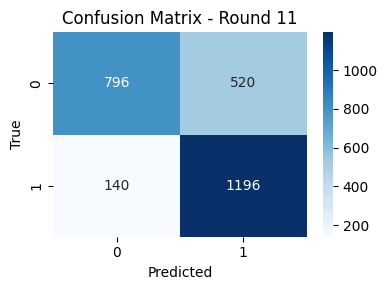

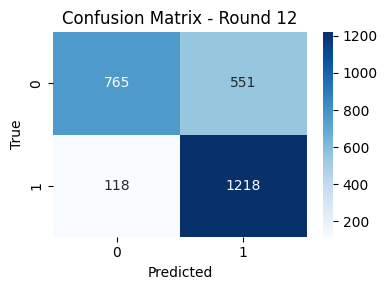

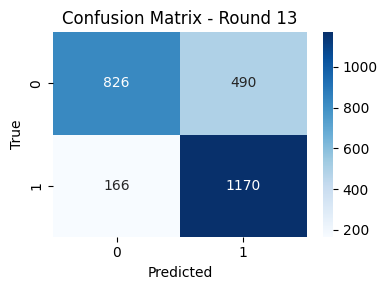

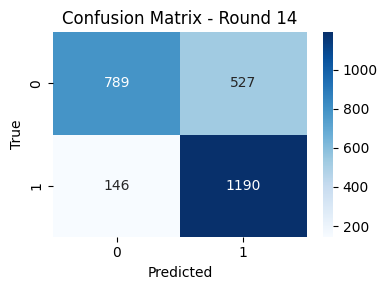

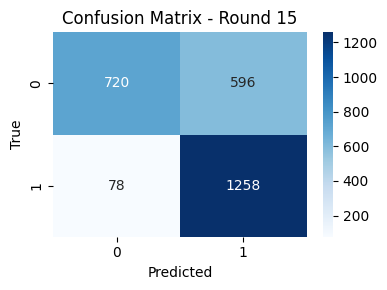

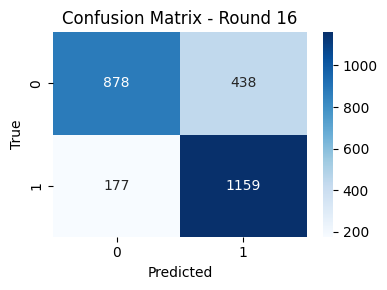

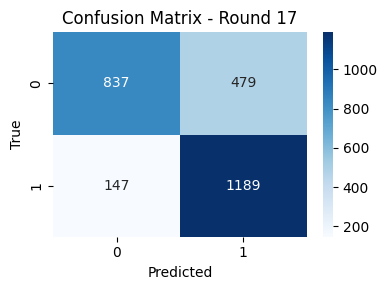

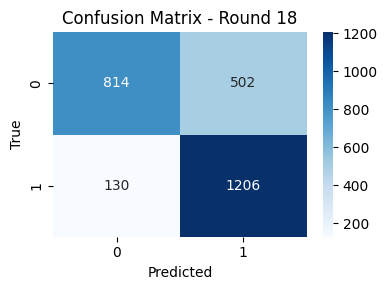

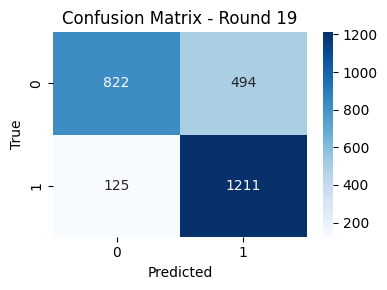

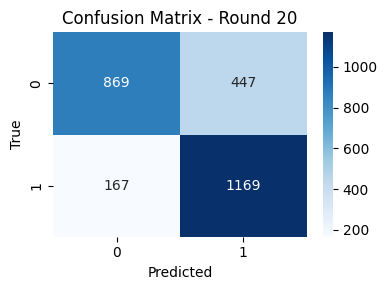

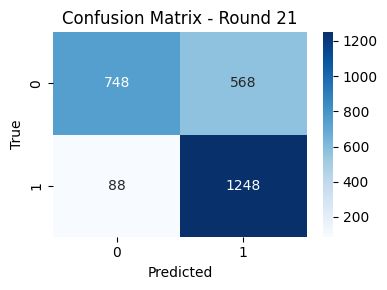

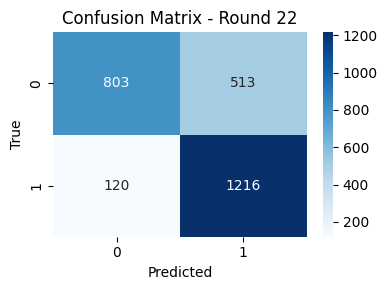

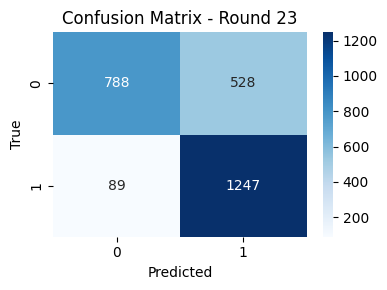

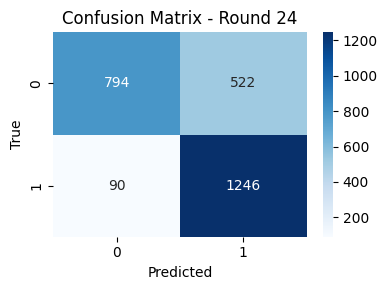

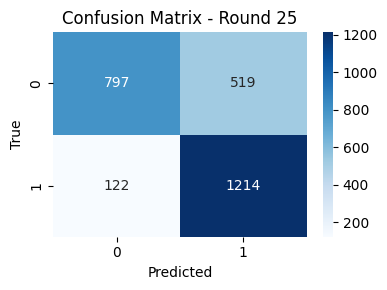

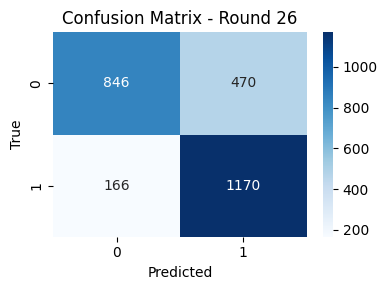

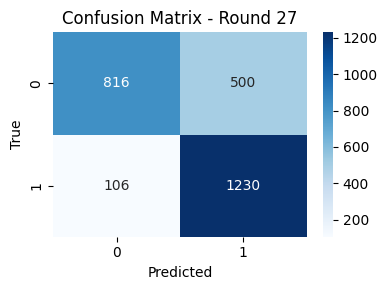

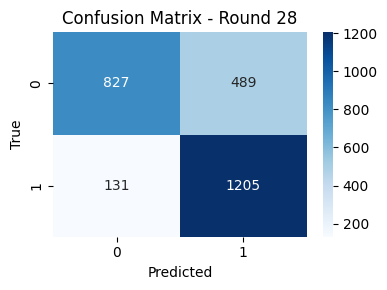

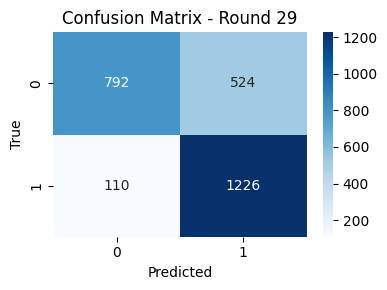

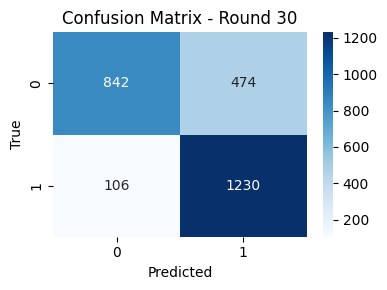

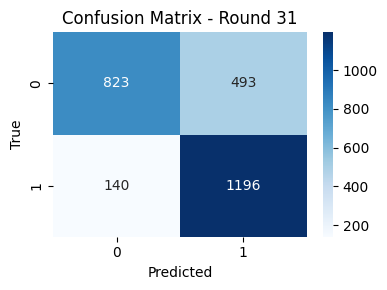

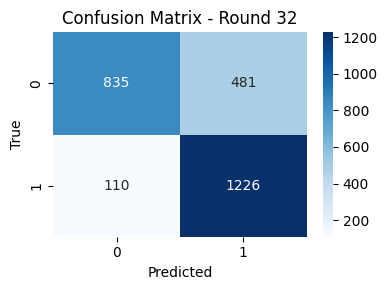

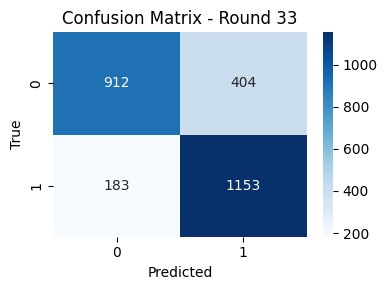

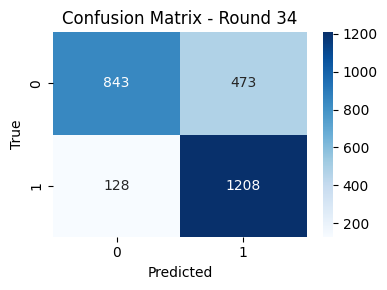

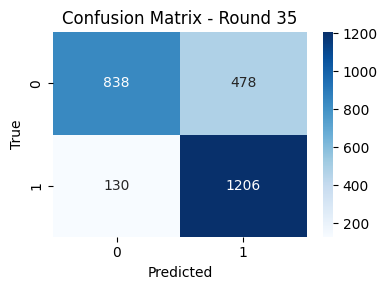

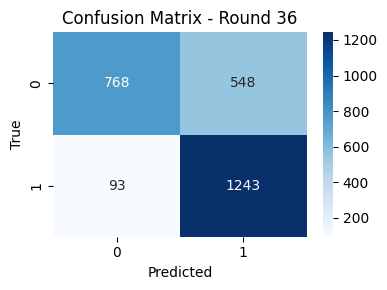

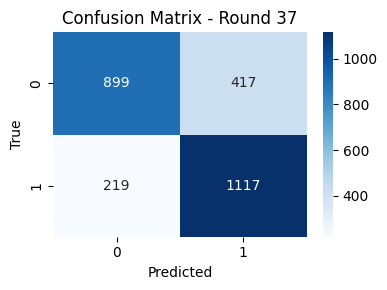

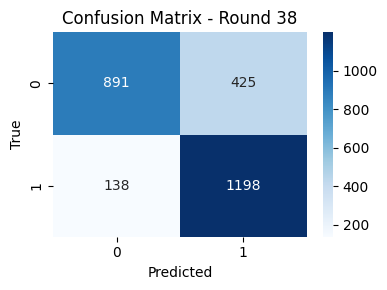

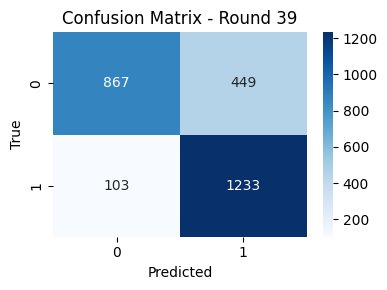

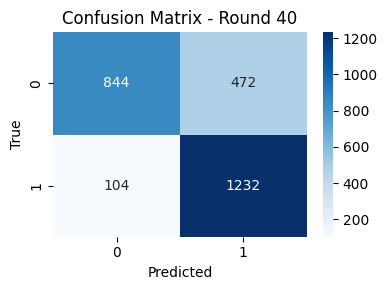

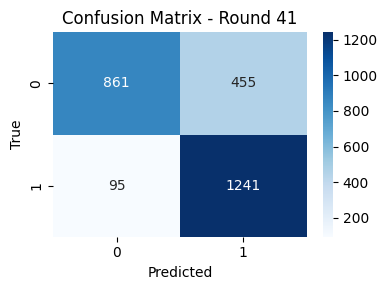

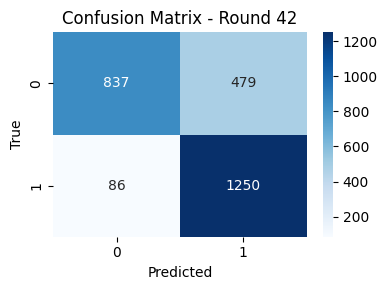

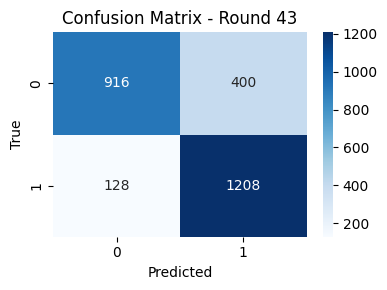

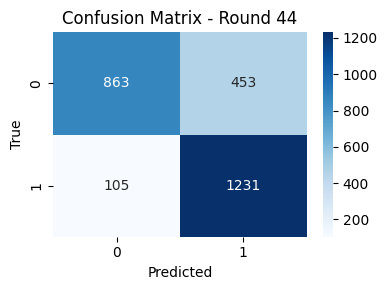

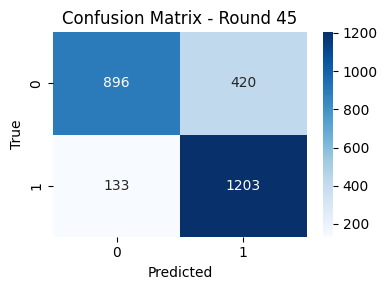

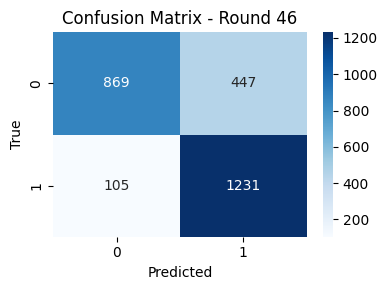

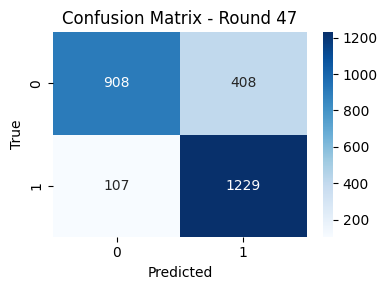

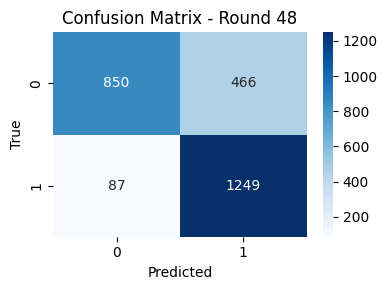

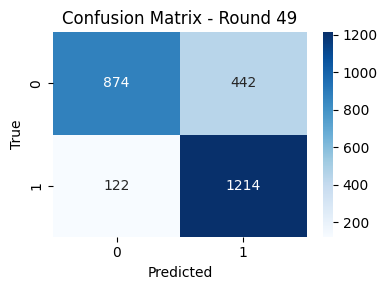

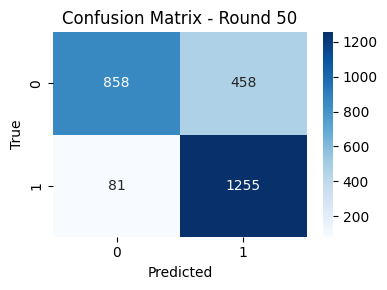

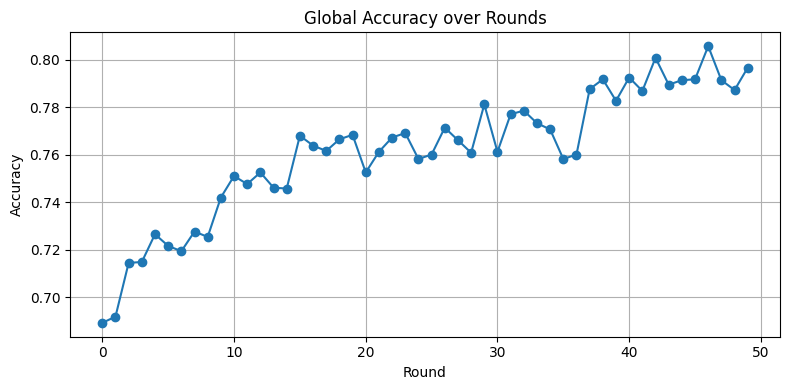

In [ ]:
# ============================================================
# Federated Learning (DeepMLP) + αᵢ Mitigation (n_i, c_i, t_i)
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation
# + Round별 Global / Local Accuracy & Confusion Matrix 로깅
# + 최종 Global / Per-Client Fine-tuning 평가
# ============================================================

import os, math, copy, random, argparse
import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# 0) 재현성 & Defect 라벨 정의
# ------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']

# αᵢ 하이퍼파라미터 (Grid-search로 선정된 값)
RHO   = 1.2   # 데이터 수(n_i) 민감도
BETA  = 1.0   # 클래스 다양성(c_i) 민감도
THETA = 1.0   # 참여도(t_i) 민감도

# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
# ------------------------------------------------
def oversample_dataset(X, y):
    """SMOTE로 class 0/1 비율을 1:1에 가깝게 맞추는 함수 (양적 균형만 맞춤)."""
    sm = SMOTE(random_state=SEED, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path: str):
    """
    - 엑셀에서 결측/무한/비수치 제거
    - DEFECT_LABELS 합쳐서 binary label (0: 정상, 1: 결함)
    - SMOTE로 oversampling
    """
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 결함 라벨 합쳐서 0/1 binary
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처: 수치형만 사용
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]

    # SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    """
    - 각 클라이언트별로: 엑셀 로드 → SMOTE → 공통 컬럼 교집합만 사용
    - 클라이언트 내부에서 평균0, 표준편차1로 표준화
    - 8:2 train/test split
    """
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 모든 클라이언트에서 공통으로 존재하는 feature만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()

        # 클라이언트별 Standardization
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)

        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test  = n - n_train

        tr, te = random_split(
            allset,
            [n_train, n_test],
            generator=torch.Generator().manual_seed(SEED)
        )

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)

# ------------------------------------------------
# 2) DeepMLP 모델 정의
# ------------------------------------------------
class DeepMLP(nn.Module):
    """
    입력: input_dim 차원 → 3개의 은닉층 (128-128-64) + Dropout + BN
    출력: binary classification (2 클래스)
    """
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------
# 3) Focal Loss (불균형 학습 난이도 완화)
# ------------------------------------------------
class FocalLoss(nn.Module):
    """
    alpha: 양/음성 가중 (여기서는 전체 scale factor)
    gamma: easy sample down-weighting 강도 (크면 어려운 샘플에 더 집중)
    """
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)  # 예측이 맞을수록 pt ↑
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

# ------------------------------------------------
# 4) αᵢ 구성요소 및 FedBN Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    """
    c_i: 클라이언트 i의 label 다양성
    - H: Shannon entropy
    - logK: 가능한 클래스 수 (여기선 binary지만 일반형으로 유지)
    - k_i: 실제로 충분히 등장한 클래스 개수
    => c_i = (k_i/K) * (H_tilde / logK)
    """
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    # Shannon entropy
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK   # entropy가 너무 0에 가까워지지 않게 바닥값
    H_tilde = max(H, H_floor)

    # min_samples 이상 등장한 클래스만 카운트
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))

def aggregate_with_softmax_weights(state_dicts, alpha_components,
                                   rho=RHO, beta=BETA, theta=THETA,
                                   use_fedbn=True):
    """
    αᵢ = softmax( log(nᵢ^ρ) + log(cᵢ^β) + log(tᵢ^θ) )
    - nᵢ: 데이터 양 기반 (여기선 sqrt(n_samples))
    - cᵢ: label 다양성 (compute_ci)
    - tᵢ: 참여도 (participation_probs)
    FedBN-style:
      - BN 관련 파라미터는 클라이언트별로 유지 (Global aggregation에서 제외)
    """
    if not state_dicts:
        return None

    # 1) 로그 도메인에서 합산
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"] ** rho + 1e-12)
            + math.log(comp["c_i"] ** beta + 1e-12)
            + math.log(comp["t_i"] ** theta + 1e-12)
        )

    # 2) softmax 정규화
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp  = sum(exp_logits.values())
    alphas     = {cid: exp_logits[cid] / total_exp for cid in logits}

    # 3) FedBN-style 모델 파라미터 집계
    base_sd  = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        # BatchNorm(혹은 running_mean/var) 는 개인화 유지
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items())
            global_sd[k] = agg.clone()

    return global_sd

# ------------------------------------------------
# 5) Local Train (FedProx 적용)
# ------------------------------------------------
def local_train(base_model, dataset, lr, epochs, device,
                global_params=None, mu=0.0):
    """
    FedProx-style 로컬 학습:
      loss_local = FocalLoss + (mu/2) * ||w_local - w_global||^2
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    if mu > 0.0 and global_params is None:
        global_params = [p.detach().clone() for p in base_model.parameters()]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx term
            if mu > 0.0 and global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()

# ------------------------------------------------
# 6) 평가 함수 (threshold 적용)
# ------------------------------------------------
def evaluate(model, dataset, device, threshold=0.5, return_preds=False):
    """
    - softmax로 class 1 확률 뽑고
    - threshold 기준으로 0/1 결정
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=256)

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()

            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    if return_preds:
        return acc, y_true, y_pred
    return acc

def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.30, 0.51, 0.05)):
    """
    여러 threshold에 대해 F1(binary) 확인 후 best threshold 선택
    """
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, yt, yp = evaluate(model, dataset, device,
                             threshold=t, return_preds=True)
        f1 = f1_score(yt, yp, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_t, best_f1 = t, f1

    print(f"\n Best threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t, best_f1

# ------------------------------------------------
# 7) Main Loop (연합학습 + 로깅 + 시각화)
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds",    type=int,   default=50)
    parser.add_argument("--mu",        type=float, default=0.003)  # FedProx 계수
    parser.add_argument("--ft_epochs", type=int,   default=5)      # per-client fine-tuning epoch
    args, _ = parser.parse_known_args()

    # 1) 클라이언트 데이터 로드
    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 입력 차원 잡기 (A 기준)
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim=input_dim,
                           hidden_dim=128,
                           num_classes=2).to(device)

    # 참여 확률 (A,C = 중견 / B,D = 중소)
    participation_probs = {"A": 0.9, "C": 0.7, "B": 0.4, "D": 0.4}

    # 전체 test set (global 평가용)
    combined_test = torch.utils.data.ConcatDataset(
        [v["test"] for v in clients.values()]
    )

    # 라운드별 로그
    global_acc_history = []                         # round별 global accuracy
    local_acc_history  = {cid: [] for cid in clients.keys()}  # round별 local accuracy
    round_conf_matrices = {}                        # round → confusion matrix

    rounds = args.rounds

    # 2) Federated Training Loop
    for rnd in range(1, rounds + 1):
        print(f"\n=== Round {rnd} ===")

        # 참여 클라이언트 샘플링
        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]

        print(f" Participating: {selected}")

        # aggregation 위한 dict들
        state_dicts      = {}
        alpha_components = {}

        # 라운드 시작 전 global accuracy
        before_acc = evaluate(global_model, combined_test, device, threshold=0.5)

        # FedProx용 global_params snapshot
        global_params = [p.detach().clone() for p in global_model.parameters()]

        # 모든 클라이언트에 대해 local_acc 기록용: 참여 안 한 경우 NaN
        for cid in clients.keys():
            local_acc_history[cid].append(float('nan'))

        # 로컬 학습
        for cid in selected:
            ds_train = clients[cid]["train"]

            # label 분포 계산 (c_i용)
            labels = [int(y) for _, y in ds_train]
            class_counts = pd.Series(labels).value_counts().to_dict()

            # local train
            state_dict = local_train(
                base_model=global_model,
                dataset=ds_train,
                lr=0.0008,
                epochs=5,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = state_dict

            # αᵢ 구성요소: n_i, c_i, t_i
            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]

            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

            # 현재 라운드에서 "local 모델" 성능도 기록
            temp_model = copy.deepcopy(global_model)
            temp_model.load_state_dict(state_dict)
            acc_local = evaluate(temp_model, clients[cid]["test"], device, threshold=0.5)
            local_acc_history[cid][-1] = acc_local
            print(f"  [Client {cid}] Local Accuracy: {acc_local:.4f}")

        # FedBN-style Aggregation (FedAvg 가중치에 αᵢ 반영)
        new_global_sd = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO,
            beta=BETA,
            theta=THETA,
            use_fedbn=True
        )
        if new_global_sd is None:
            continue

        global_model.load_state_dict(new_global_sd)

        # 라운드 후 global 평가 + confusion matrix 계산
        after_acc, yt_round, yp_round = evaluate(
            global_model, combined_test, device,
            threshold=0.5, return_preds=True
        )
        global_acc_history.append(after_acc)
        print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f}")

        cm = confusion_matrix(yt_round, yp_round, labels=[0, 1])
        round_conf_matrices[rnd] = cm
        print("\n Confusion Matrix (Round {})".format(rnd))
        print(cm)

    # ------------------------------------------------
    # 3) Global 최종 평가 + best threshold 탐색
    # ------------------------------------------------
    print("\n=== Global Evaluation (with Best Threshold Search) ===")
    best_t, best_f1 = find_best_threshold(global_model, combined_test, device)
    global_acc, yt, yp = evaluate(global_model, combined_test, device,
                                  threshold=best_t, return_preds=True)
    print(f"\nFinal Global Accuracy: {global_acc:.4f}")
    print(classification_report(yt, yp, digits=4))

    # ------------------------------------------------
    # 4) Per-Client Fine-tuning (Personalization)
    # ------------------------------------------------
    print("\n=== Per-Client Fine-tuning ===")
    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")
        # global_model을 시작점으로 client별 추가 local epochs
        ft_state = local_train(
            base_model=global_model,
            dataset=data["train"],
            lr=0.0008,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,  # fine-tuning 시에는 FedProx term off
            mu=0.0
        )
        local_model = copy.deepcopy(global_model)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(local_model, data["test"], device,
                                     threshold=best_t, return_preds=True)
        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print(classification_report(yt_c, yp_c, digits=4))

    # ------------------------------------------------
    # 5) 시각화: 라운드별 Global Accuracy & Local Accuracy
    # ------------------------------------------------
    rounds_axis = list(range(1, rounds + 1))

    # (1) Global Accuracy
    plt.figure(figsize=(10,4))
    plt.plot(rounds_axis, global_acc_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Global Accuracy")
    plt.title(f"Global Accuracy over Rounds (rho={RHO}, beta={BETA}, theta={THETA})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # (2) Local Accuracy per Client (참여한 라운드만 값, 나머지는 NaN)
    plt.figure(figsize=(10,4))
    for cid in clients.keys():
        plt.plot(rounds_axis, local_acc_history[cid], marker='o', label=f"Client {cid}")
    plt.xlabel("Round")
    plt.ylabel("Local Test Accuracy after Local Train (thr=0.5)")
    plt.title("Per-Client Local Accuracy over Rounds")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # (6) Round별 Confusion Matrix Heatmap 출력
    # ---------------------------------------------------------
    for rnd, cm in round_conf_matrices.items():
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=[0,1], yticklabels=[0,1])
        plt.title(f"Confusion Matrix - Round {rnd}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # (7) 최종 Global Accuracy Trend만
    # ---------------------------------------------------------
    plt.figure(figsize=(8,4))
    plt.plot(global_acc_history, marker='o')
    plt.title("Global Accuracy over Rounds")
    plt.xlabel("Round")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Accuracy가 떨어지면 자동으로 롤백(Adaptive Rollback)

[Client A] after SMOTE → shape: (5662, 16), class balance: {0: 2831, 1: 2831}
[Client B] after SMOTE → shape: (948, 16), class balance: {0: 474, 1: 474}
[Client C] after SMOTE → shape: (5830, 16), class balance: {0: 2915, 1: 2915}
[Client D] after SMOTE → shape: (812, 16), class balance: {0: 406, 1: 406}

=== Round 1 (Rollback Enabled) ===
Participating: ['A', 'B', 'C', 'D']
  [Client A] Local Accuracy: 0.6840
  [Client B] Local Accuracy: 0.7421
  [Client C] Local Accuracy: 0.7136
  [Client D] Local Accuracy: 0.8037
[Round 1] Global Accuracy: 0.4962 → 0.6859

=== Round 2 (Rollback Enabled) ===
Participating: ['A', 'D']
  [Client A] Local Accuracy: 0.7087
  [Client D] Local Accuracy: 0.7914
[Round 2] Global Accuracy: 0.6859 → 0.7066

=== Round 3 (Rollback Enabled) ===
Participating: ['A', 'B', 'C']
  [Client A] Local Accuracy: 0.7211
  [Client B] Local Accuracy: 0.8000
  [Client C] Local Accuracy: 0.7453
[Round 3] Global Accuracy: 0.7066 → 0.7123

=== Round 4 (Rollback Enabled) ===
Part

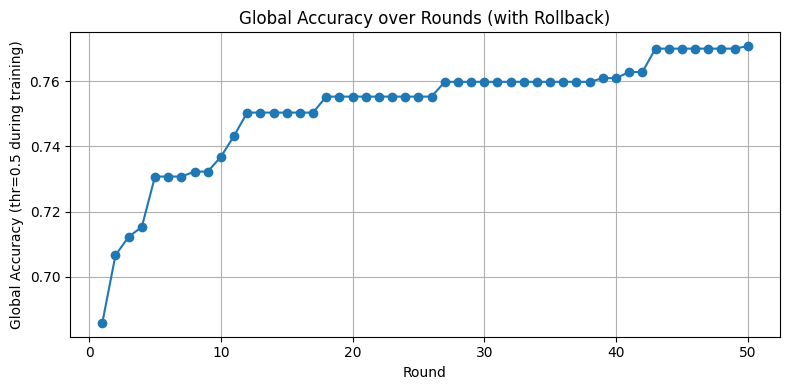

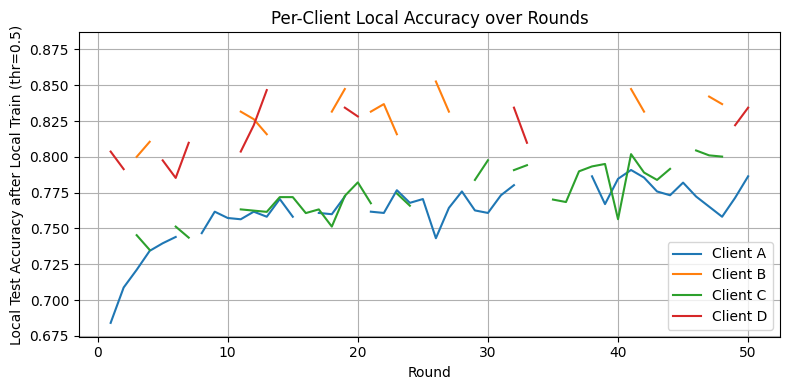


Best Global Accuracy (with rollback) = 0.7707 at Round 50


In [7]:
# ============================================================
# Federated Learning (DeepMLP) + αᵢ Mitigation (n_i, c_i, t_i)
# + SMOTE + FocalLoss + FedProx + FedBN-style Aggregation
# + Participation Skew (A,C teacher / B,D SME)
# + Round별 Rollback (Global Accuracy 하락 시 이전 모델로 복구)
# + Global / Per-Client Evaluation + Accuracy Trend Plot
# ============================================================

import os, math, copy, random, argparse
from collections import Counter

import pandas as pd
import numpy as np
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import classification_report, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ------------------------------------------------
# 0) 재현성 & Defect 라벨 정의
# ------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEFECT_LABELS = ['Short_Shot_1', 'Bubble_1', 'Exfoliation_1', 'Blow_Hole_1', 'Deformation_1']

# αᵢ 하이퍼파라미터 (Grid-search로 선정된 값)
RHO   = 1.2   # 데이터 수(n_i) 민감도
BETA  = 1.0   # 클래스 다양성(c_i) 민감도
THETA = 1.0   # 참여도(t_i) 민감도

# ------------------------------------------------
# 1) 데이터 로드 + SMOTE Oversampling
# ------------------------------------------------
def oversample_dataset(X, y):
    """SMOTE로 class 0/1 비율을 1:1에 맞추는 함수 (양적 균형만 맞춤)."""
    sm = SMOTE(random_state=SEED, k_neighbors=5)
    X_res, y_res = sm.fit_resample(X, y)
    return X_res, y_res

def load_excel_binary(path: str):
    """
    - 엑셀에서 결측/무한/비수치 제거
    - DEFECT_LABELS 합쳐서 binary label (0: 정상, 1: 결함)
    - SMOTE로 oversampling
    """
    df = pd.read_excel(path).dropna(axis=1, how='all')

    for col in DEFECT_LABELS:
        if col not in df.columns:
            df[col] = 0

    # 결함 라벨 합쳐서 0/1 binary
    y = df[DEFECT_LABELS].sum(axis=1).clip(upper=1).astype(int).values

    # 입력 피처: 수치형만 사용
    X = (
        df.drop(columns=DEFECT_LABELS, errors='ignore')
          .select_dtypes(include=[np.number])
          .replace([np.inf, -np.inf], np.nan)
          .dropna(axis=0, how='any')
    )
    y = y[:len(X)]

    # SMOTE 적용
    X_res, y_res = oversample_dataset(X, y)
    return X_res, y_res

def build_clients(path_map):
    """
    - 각 클라이언트별로: 엑셀 로드 → SMOTE → 공통 컬럼 교집합만 사용
    - 클라이언트 내부에서 평균0, 표준편차1로 표준화
    - 8:2 train/test split
    """
    raw = {}
    for cid, path in path_map.items():
        X, y = load_excel_binary(path)
        raw[cid] = {"X": X, "y": y}
        print(f"[Client {cid}] after SMOTE → shape: {X.shape}, class balance: {pd.Series(y).value_counts().to_dict()}")

    # 모든 클라이언트에서 공통으로 존재하는 feature만 사용
    cols = set.intersection(*[set(v["X"].columns) for v in raw.values()])

    clients, metas = {}, {}
    for cid, v in raw.items():
        feat = v["X"][list(cols)].copy()

        # 클라이언트별 Standardization
        mu, sigma = feat.mean(), feat.std().replace(0, 1)
        feat = (feat - mu) / sigma

        X = torch.tensor(feat.values.astype(np.float32))
        y = torch.tensor(v["y"], dtype=torch.long)

        allset = TensorDataset(X, y)
        n = len(allset)
        n_train = int(0.8 * n)
        n_test  = n - n_train

        tr, te = random_split(
            allset,
            [n_train, n_test],
            generator=torch.Generator().manual_seed(SEED)
        )

        clients[cid] = {"train": tr, "test": te, "all": allset}
        metas[cid] = {
            "n_samples": len(y),
            "class_counts": pd.Series(v["y"]).value_counts().to_dict()
        }

    return clients, metas, list(cols)

# ------------------------------------------------
# 2) DeepMLP 모델 정의
# ------------------------------------------------
class DeepMLP(nn.Module):
    """
    입력: input_dim 차원 → 3개의 은닉층 (128-128-64) + Dropout + BN
    출력: binary classification (2 클래스)
    """
    def __init__(self, input_dim, hidden_dim=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# ------------------------------------------------
# 3) Focal Loss (불균형 학습 난이도 완화)
# ------------------------------------------------
class FocalLoss(nn.Module):
    """
    alpha: 양/음성 전체 스케일 팩터
    gamma: easy sample down-weighting 강도
    """
    def __init__(self, alpha=2.0, gamma=1.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        pt = torch.exp(-ce_loss)  # 예측이 맞을수록 pt ↑
        loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return loss.mean()

# ------------------------------------------------
# 4) αᵢ 구성요소 및 FedBN Aggregation
# ------------------------------------------------
def compute_ci(class_counts, eps_frac=0.05, min_samples=1):
    """
    c_i: 클라이언트 i의 label 다양성
    - H: Shannon entropy
    - logK: 가능한 클래스 수
    - k_i: 충분히 등장한 클래스 개수
    => c_i = (k_i/K) * (H_tilde / logK)
    """
    K = len(class_counts)
    total = sum(class_counts.values())
    if K == 0 or total == 0:
        return 1e-8

    # Shannon entropy
    H = -sum((c / total) * math.log(c / total) for c in class_counts.values() if c > 0)

    logK = math.log(K + 1e-12)
    H_floor = eps_frac * logK   # 바닥값
    H_tilde = max(H, H_floor)

    # min_samples 이상 등장한 클래스만 카운트
    k_i = sum(1 for c in class_counts.values() if c >= min_samples)
    frac_k = k_i / K

    return max(1e-8, frac_k * (H_tilde / logK))

def aggregate_with_softmax_weights(state_dicts, alpha_components,
                                   rho=RHO, beta=BETA, theta=THETA,
                                   use_fedbn=True):
    """
    αᵢ = softmax( log(nᵢ^ρ) + log(cᵢ^β) + log(tᵢ^θ) )
    - nᵢ: 데이터 양 기반 (여기선 sqrt(n_samples))
    - cᵢ: label 다양성 (compute_ci)
    - tᵢ: 참여도 (participation_probs)
    FedBN-style:
      - BN 관련 파라미터는 클라이언트별로 유지 (Global aggregation에서 제외)
    """
    if not state_dicts:
        return None

    # 1) 로그 도메인에서 합산
    logits = {}
    for cid, comp in alpha_components.items():
        logits[cid] = (
            math.log(comp["n_i"] ** rho + 1e-12)
            + math.log(comp["c_i"] ** beta + 1e-12)
            + math.log(comp["t_i"] ** theta + 1e-12)
        )

    # 2) softmax 정규화
    max_logit = max(logits.values())
    exp_logits = {cid: math.exp(logits[cid] - max_logit) for cid in logits}
    total_exp  = sum(exp_logits.values())
    alphas     = {cid: exp_logits[cid] / total_exp for cid in logits}

    # 3) FedBN-style 모델 파라미터 집계
    base_sd  = next(iter(state_dicts.values()))
    global_sd = {}

    for k in base_sd.keys():
        # BatchNorm(혹은 running_mean/var) 는 개인화 유지
        if use_fedbn and ("bn" in k or "running_mean" in k or "running_var" in k):
            global_sd[k] = base_sd[k].clone()
        else:
            agg = sum(sd[k] * alphas[cid] for cid, sd in state_dicts.items())
            global_sd[k] = agg.clone()

    return global_sd

# ------------------------------------------------
# 5) Local Train (FedProx 적용)
# ------------------------------------------------
def local_train(base_model, dataset, lr, epochs, device,
                global_params=None, mu=0.0):
    """
    FedProx-style 로컬 학습:
      loss_local = FocalLoss + (mu/2) * ||w_local - w_global||^2
    """
    model = copy.deepcopy(base_model).to(device)
    model.train()

    crit = FocalLoss(alpha=2.0, gamma=1.5)
    opt  = optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    # global_params가 없으면 base_model 기준으로 snapshot
    if mu > 0.0 and global_params is None:
        global_params = [p.detach().clone() for p in base_model.parameters()]

    for _ in range(epochs):
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            logits = model(x)
            loss = crit(logits, y)

            # FedProx term
            if mu > 0.0 and global_params is not None:
                prox = 0.0
                for p, g in zip(model.parameters(), global_params):
                    prox += torch.norm(p - g) ** 2
                loss = loss + 0.5 * mu * prox

            loss.backward()
            opt.step()

    return model.state_dict()

# ------------------------------------------------
# 6) 평가 함수 (threshold 적용)
# ------------------------------------------------
def evaluate(model, dataset, device, threshold=0.5, return_preds=False):
    """
    - softmax로 class 1 확률 뽑고
    - threshold 기준으로 0/1 결정
    """
    model.eval()
    loader = DataLoader(dataset, batch_size=256)

    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            probs = torch.softmax(model(x), dim=1)[:, 1]
            preds = (probs > threshold).long()

            y_true += y.cpu().tolist()
            y_pred += preds.cpu().tolist()

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    if return_preds:
        return acc, y_true, y_pred
    return acc

def find_best_threshold(model, dataset, device,
                        thresholds=np.arange(0.30, 0.51, 0.05)):
    """
    여러 threshold에 대해 F1(binary) 확인 후 best threshold 선택
    """
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        _, yt, yp = evaluate(model, dataset, device,
                             threshold=t, return_preds=True)
        f1 = f1_score(yt, yp, average='binary', zero_division=0)
        print(f"Threshold={t:.2f}, F1={f1:.4f}")
        if f1 > best_f1:
            best_t, best_f1 = t, f1

    print(f"\nBest threshold = {best_t:.2f} (F1={best_f1:.4f})")
    return best_t, best_f1

# ------------------------------------------------
# 7) Main Loop (연합학습 + Rollback + 평가 + 시각화)
# ------------------------------------------------
if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--rounds",    type=int,   default=50)
    parser.add_argument("--mu",        type=float, default=0.003)  # FedProx 계수
    parser.add_argument("--ft_epochs", type=int,   default=5)      # per-client fine-tuning epoch
    args, _ = parser.parse_known_args()

    # 1) 클라이언트 데이터 로드
    paths = {"A": "A.xlsx", "B": "B.xlsx", "C": "C.xlsx", "D": "D.xlsx"}
    clients, metas, cols = build_clients(paths)

    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 입력 차원 (A 기준)
    input_dim = clients["A"]["all"].tensors[0].shape[1]
    global_model = DeepMLP(input_dim=input_dim,
                           hidden_dim=128,
                           num_classes=2).to(device)

    # 참여 확률: A,C(중견 teacher) > B,D(중소 SME)
    participation_probs = {
        "A": 0.9,   # 중견
        "C": 0.7,   # 중견
        "B": 0.4,   # 중소
        "D": 0.4    # 중소
    }

    # 전체 test set (global 평가용)
    combined_test = torch.utils.data.ConcatDataset(
        [v["test"] for v in clients.values()]
    )

    rounds = args.rounds

    # 라운드별 로그
    global_acc_history = []                       # round별 global accuracy (rollback 후 결과)
    local_acc_history  = {cid: [] for cid in clients.keys()}  # round별 local accuracy

    # Rollback 기준 best 모델 저장용
    best_round = 0
    best_acc   = 0.0
    best_state_dict = copy.deepcopy(global_model.state_dict())

    # 2) Federated Training Loop (Rollback 적용)
    for rnd in range(1, rounds + 1):
        print(f"\n=== Round {rnd} (Rollback Enabled) ===")

        # 라운드 시작 전 global snapshot
        prev_state = copy.deepcopy(global_model.state_dict())
        before_acc = evaluate(global_model, combined_test, device, threshold=0.5)

        # 참여 클라이언트 샘플링
        selected = [cid for cid in clients if random.random() < participation_probs[cid]]
        if len(selected) == 0:
            selected = [random.choice(list(clients.keys()))]

        print(f"Participating: {selected}")

        # FedProx용 global_params snapshot
        global_params = [p.detach().clone() for p in global_model.parameters()]

        state_dicts      = {}
        alpha_components = {}

        # 모든 클라이언트에 대해 local_acc 기록용: 참여 안 한 경우 NaN
        for cid in clients.keys():
            local_acc_history[cid].append(float('nan'))

        # 로컬 학습
        for cid in selected:
            # c_i 계산용 label 분포
            labels = []
            for _, y in clients[cid]["train"]:
                labels.append(int(y))
            class_counts = dict(Counter(labels))

            # local train
            sd = local_train(
                base_model=global_model,
                dataset=clients[cid]["train"],
                lr=0.0008,
                epochs=5,
                device=device,
                global_params=global_params,
                mu=args.mu
            )
            state_dicts[cid] = sd

            # αᵢ 구성요소
            n_i = math.sqrt(metas[cid]["n_samples"])
            c_i = compute_ci(class_counts)
            t_i = participation_probs[cid]
            alpha_components[cid] = {"n_i": n_i, "c_i": c_i, "t_i": t_i}

            # local accuracy (해당 클라이언트 test 기준)
            temp_model = copy.deepcopy(global_model)
            temp_model.load_state_dict(sd)
            acc_local = evaluate(temp_model, clients[cid]["test"], device, threshold=0.5)
            local_acc_history[cid][-1] = acc_local
            print(f"  [Client {cid}] Local Accuracy: {acc_local:.4f}")

        # FedBN-style Aggregation (αᵢ 반영)
        new_global_sd = aggregate_with_softmax_weights(
            state_dicts,
            alpha_components,
            rho=RHO,
            beta=BETA,
            theta=THETA,
            use_fedbn=True
        )
        if new_global_sd is None:
            # 아무도 참여 안 한 극단 상황이라면 그냥 이전 state 유지
            global_acc_history.append(before_acc)
            continue

        global_model.load_state_dict(new_global_sd)

        # Aggregation 이후 global accuracy 측정
        after_acc = evaluate(global_model, combined_test, device, threshold=0.5)

        # Rollback 여부 판단
        if after_acc < before_acc:
            print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f}  (decrease, rollback)")
            # 이전 state로 복구
            global_model.load_state_dict(prev_state)
            global_acc_history.append(before_acc)
            final_acc_for_round = before_acc
        else:
            print(f"[Round {rnd}] Global Accuracy: {before_acc:.4f} → {after_acc:.4f}")
            global_acc_history.append(after_acc)
            final_acc_for_round = after_acc

        # best model 갱신
        if final_acc_for_round > best_acc:
            best_acc = final_acc_for_round
            best_round = rnd
            best_state_dict = copy.deepcopy(global_model.state_dict())

    # ------------------------------------------------
    # 3) Global 최종 평가 (Rollback 반영된 마지막 모델 기준)
    # ------------------------------------------------
    print("\n=== Global Evaluation (with Best Threshold Search) ===")
    best_t, best_f1 = find_best_threshold(global_model, combined_test, device)
    global_acc, yt, yp = evaluate(global_model, combined_test, device,
                                  threshold=best_t, return_preds=True)
    print(f"\nFinal Global Accuracy: {global_acc:.4f}")
    print(classification_report(yt, yp, digits=4))

    # ------------------------------------------------
    # 4) Per-Client Fine-tuning (Rollback된 최종 global_model 기준)
    # ------------------------------------------------
    print("\n=== Per-Client Fine-tuning ===")
    for cid, data in clients.items():
        print(f"\n--- Client {cid} Fine-tuning ---")
        ft_state = local_train(
            base_model=global_model,
            dataset=data["train"],
            lr=0.0008,
            epochs=args.ft_epochs,
            device=device,
            global_params=None,
            mu=0.0
        )
        local_model = copy.deepcopy(global_model)
        local_model.load_state_dict(ft_state)

        acc_c, yt_c, yp_c = evaluate(local_model, data["test"], device,
                                     threshold=best_t, return_preds=True)
        print(f"[Client {cid}] Fine-tuned Accuracy: {acc_c:.4f}")
        print(classification_report(yt_c, yp_c, digits=4))

    # ------------------------------------------------
    # 5) 시각화: 라운드별 Global Accuracy & Local Accuracy
    # ------------------------------------------------
    rounds_axis = list(range(1, rounds + 1))

    # (1) Global Accuracy Trend
    plt.figure(figsize=(8, 4))
    plt.plot(rounds_axis, global_acc_history, marker='o')
    plt.xlabel("Round")
    plt.ylabel("Global Accuracy (thr=0.5 during training)")
    plt.title("Global Accuracy over Rounds (with Rollback)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # (2) Local Accuracy per Client (참여한 라운드만 값, 나머지는 NaN)
    plt.figure(figsize=(8, 4))
    for cid in clients.keys():
        plt.plot(rounds_axis, local_acc_history[cid], label=f"Client {cid}")
    plt.xlabel("Round")
    plt.ylabel("Local Test Accuracy after Local Train (thr=0.5)")
    plt.title("Per-Client Local Accuracy over Rounds")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print(f"\nBest Global Accuracy (with rollback) = {best_acc:.4f} at Round {best_round}")


In [8]:
print(global_model.state_dict().keys())


odict_keys(['net.0.weight', 'net.0.bias', 'net.1.weight', 'net.1.bias', 'net.1.running_mean', 'net.1.running_var', 'net.1.num_batches_tracked', 'net.4.weight', 'net.4.bias', 'net.5.weight', 'net.5.bias', 'net.5.running_mean', 'net.5.running_var', 'net.5.num_batches_tracked', 'net.8.weight', 'net.8.bias', 'net.9.weight', 'net.9.bias', 'net.9.running_mean', 'net.9.running_var', 'net.9.num_batches_tracked', 'net.12.weight', 'net.12.bias'])
